In [1]:
import torch
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from mpl_toolkits.mplot3d import Axes3D  # Needed for 3D plotting
from matplotlib import cm  # Colormaps
from matplotlib import gridspec
import matplotlib.colors as mcolors
from matplotlib.patches import Patch
torch.set_default_dtype(torch.float64)
from types import SimpleNamespace
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

plt.rcParams.update({'font.size': 22})
base_dir = os.getcwd()
save_dir = os.path.join(base_dir, "graphs")
output_data_analytic = os.path.join(base_dir, "Experiment3_Magnetostatics", "analytical_example", "output_data")
output_data_ex3 = os.path.join(base_dir, "Experiment3_Magnetostatics",  "output_data")

def load_run(data_dir, fname):
    """Load a results .npz file and return its arrays as torch tensors in a namespace."""
    raw = np.load(os.path.join(data_dir, fname), allow_pickle = True)
    ns = SimpleNamespace()
    for key in raw:
        try:
            setattr(ns, key, torch.tensor(raw[key]))
        except Exception:
            setattr(ns, key, raw[key])
    return ns

# Inverse problem

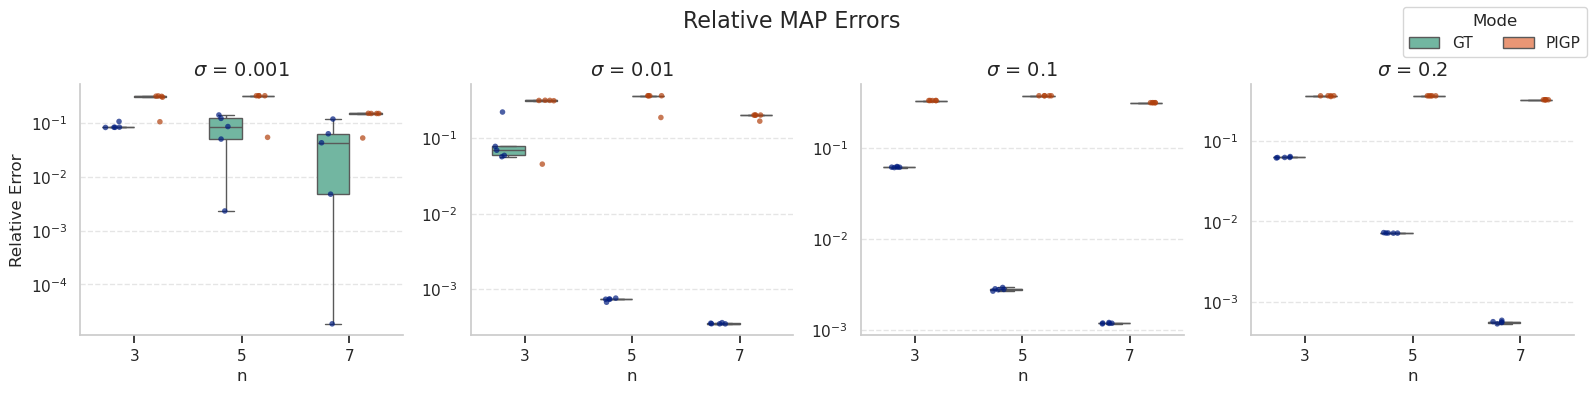

In [3]:
runs = 5
data_mode = ["extra_npoints_extra_sigma", "standard" ]
sigma_list = [0.001, 0.01, 0.1, 0.2]
n_list = [3, 5, 7]#, 5, 10]#,  30, 50]
modes = ["GT", "PIGP"]
all_AE = np.zeros((len(n_list), len(sigma_list), len(modes), 1, runs))

for n_idx, npoints in enumerate(n_list):
    for sigma_idx, sigma in enumerate(sigma_list):
        for j, mode in enumerate(modes):
            data_dir = os.path.join(output_data_ex3, data_mode[j])

            for run in range(runs):
                fname = f"Ex3_{mode}_n{npoints}_sigma{sigma:.3f}_{run}.npz"
                #try:
                data = load_run(data_dir, fname)
                
                all_AE[n_idx, sigma_idx, j, 0, run] = abs(data.nu0[-1] - 1)#
                #except:  pass
               


# --- reshape all_AE into long-form dataframe ---
records = []

display_n = ["3", "5", "7"]
for n_idx, n in enumerate(n_list):
    for sigma_idx, sigma in enumerate(sigma_list):
        for mode_idx, mode in enumerate(modes):
            for run in range(runs):
                ae = all_AE[n_idx, sigma_idx, mode_idx, 0, run]
                records.append({
                    "n": display_n[n_idx],
                    "sigma": sigma,
                    "mode": mode,
                    "data_mode": data_mode[mode_idx],
                    "AE": ae
                })

df = pd.DataFrame.from_records(records)

# categorical ordering
df["n"] = pd.Categorical(df["n"], categories=display_n, ordered=True)
df["sigma"] = pd.Categorical(df["sigma"], categories=sigma_list, ordered=True)
df["mode"] = pd.Categorical(df["mode"], categories=modes, ordered=True)
sns.set(style="whitegrid")

# --- plotting (exact same style as Ex2 inverse) ---
g = sns.FacetGrid(
    df,
    col="sigma",
    height=4,
    aspect=1.,
    sharey=False,
    margin_titles=False
)

def box_and_points(data, **kwargs):
    ax = plt.gca()
    sns.boxplot(
        data=data, x="n", y="AE", hue="mode",
        dodge=True, width=0.6, showfliers=False, palette="Set2", ax=ax
    )
    sns.stripplot(
        data=data, x="n", y="AE", hue="mode",
        dodge=True, jitter=0.15, size=4, alpha=0.7, palette="dark", ax=ax
    )
    if ax.legend_ is not None:
        ax.legend_.remove()

g.map_dataframe(box_and_points)

# single legend
handles, labels = g.axes.flat[0].get_legend_handles_labels()
g.figure.legend(handles[:2], labels[:2], title="Mode", ncol=2)

# formatting: sigma in the subtitle (no parameter name)
nrows, ncols = g.axes.shape
for i in range(nrows):
    for j in range(ncols):
        ax = g.axes[i, j]
        ax.set_yscale("log")
        ax.grid(True, axis="y", linestyle="--", alpha=0.5)
        ax.set_title(rf"$\sigma$ = {g.col_names[j]}", fontsize=14)
        # keep x ticks on every panel, tick labels only on the bottom row
        ax.tick_params(axis="x", which="both", bottom=True, labelbottom=(i == nrows - 1))

g.set_axis_labels("n", "Relative Error")

g.figure.suptitle("Relative MAP Errors", fontsize=16)
g.figure.tight_layout()
#g.figure.subplots_adjust(top=0.90)

plt.savefig(os.path.join(save_dir, "Ex3_inverse.pdf"), bbox_inches="tight")

# Forward plots for GT (8 subplots) and PIGP (9 subplots)

used training points torch.Size([792])


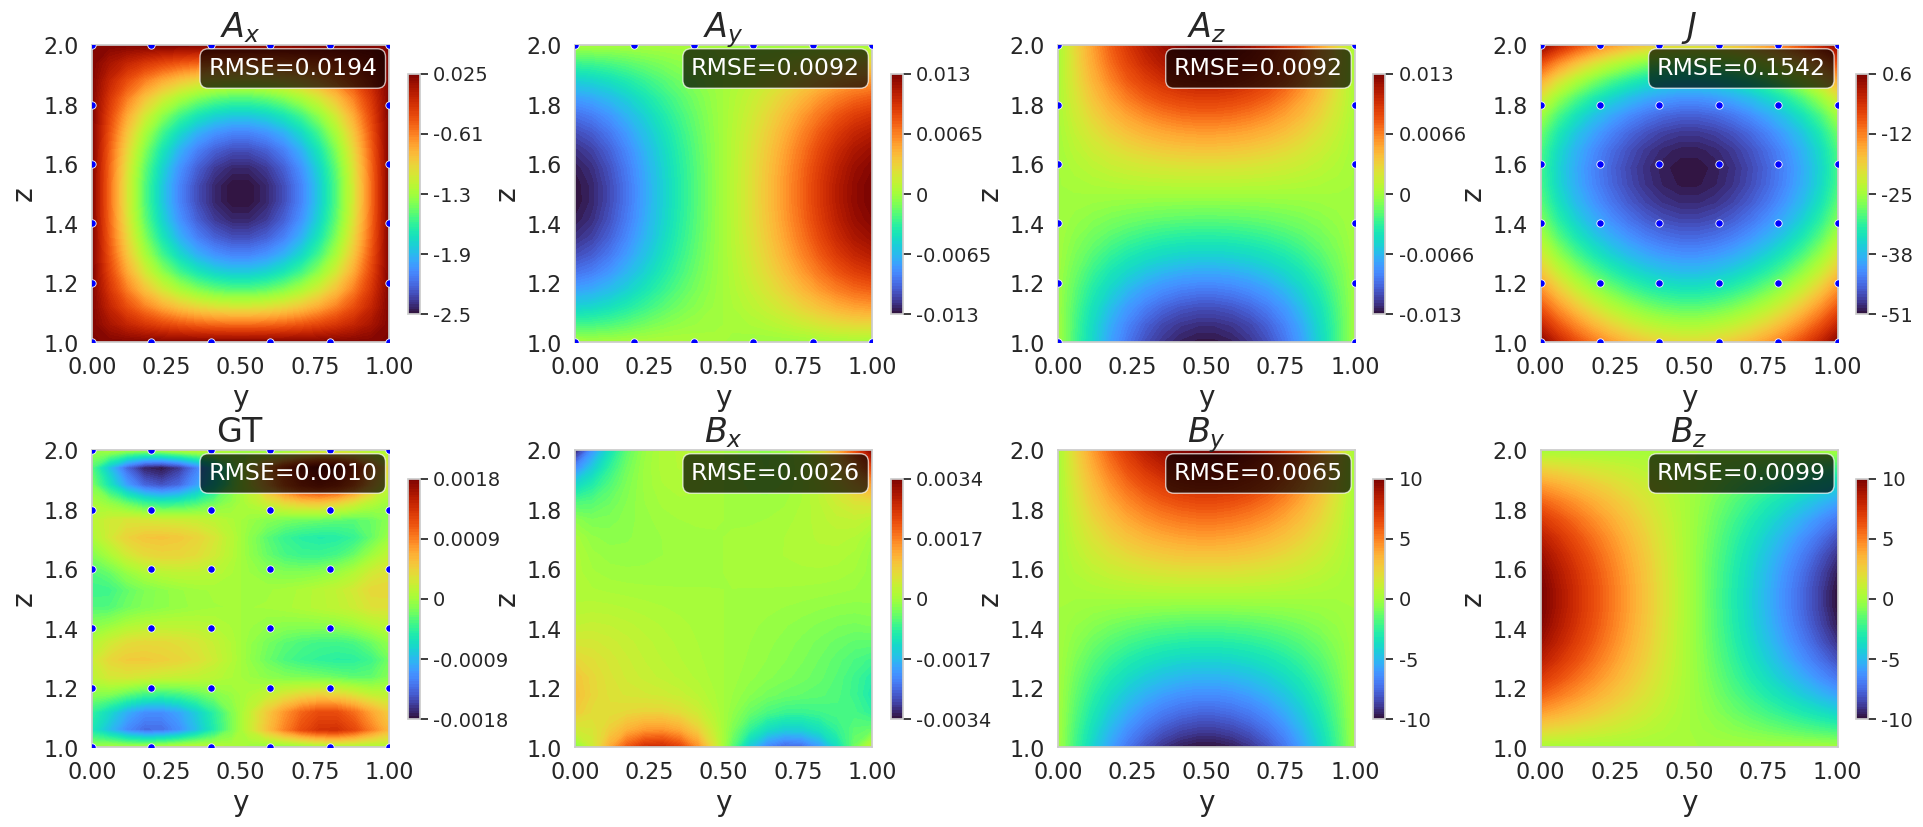

In [27]:
import matplotlib.ticker as mticker


def style_cbar(cbar, surf, n_ticks=5):
    """Paper-ready colorbar: few ticks, 2 significant digits, no scientific-
    notation offset header floating in the figure (same as Ex1 forward)."""
    vmin, vmax = surf.get_clim()
    cbar.set_ticks(np.linspace(vmin, vmax, n_ticks))
    cbar.ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:.2g}"))
    cbar.ax.yaxis.get_offset_text().set_visible(False)
    cbar.ax.tick_params(labelsize=14)


# per-subplot cell size in inches; shared with the PIGP cell so panels in both
# figures come out exactly the same size (figsize = n_cols/rows * cell size)
CELL_W, CELL_H = 5.0, 4.3

data_dir = os.path.join(output_data_ex3, "forward")
fname = f"Ex3_GT.npz"
data = load_run(data_dir, fname)

nrows, ncols = 2, 4
fig, ax = plt.subplots(nrows, ncols, figsize=(ncols * CELL_W, nrows * CELL_H))
print("used training points", data.train_y.shape)

test_n = 18
xxx = torch.linspace(0, 1, test_n)
yyy = torch.linspace(0, 1, test_n)
zzz = torch.linspace(1, 2, test_n)
tx, ty, tz = torch.meshgrid(xxx, yyy, zzz, indexing="ij")

# put the slice on the test node closest to a training x-layer, so the training
# points actually lie in the visible y-z plane (solution has no x-dependence)
train_layers = torch.unique(data.train_x[:, 0])
x_near = float(train_layers[(train_layers - float(xxx[test_n // 2])).abs().argmin()])
x_idx = int((xxx - x_near).abs().argmin())
X = ty[x_idx, :, :]
Y = tz[x_idx, :, :]

#for visualizations:
title = [r"$A_x$", r"$A_y$", r"$A_z$", r"$J$", r"$\mathrm{GT}$", r"$B_x$", r"$B_y$", r"$B_z$"]
for i in range(8):
    a = ax[i // 4, i % 4]
    mask = data.test_x[:, -1] == i

    Z = data.mean[mask].reshape(test_n, test_n, test_n)[x_idx, :, :]

    cf = a.contourf(X, Y, Z, levels=100, cmap="turbo")
    cbar = fig.colorbar(cf, ax=a, shrink=0.7)
    style_cbar(cbar, cf)
    a.set_title(title[i], fontsize=24)

    # training points lying in the visible slice (B-field tasks have none)
    tmask = (data.train_x[:, -1] == i) & ((data.train_x[:, 0] - x_near).abs() < 1e-6)
    if bool(tmask.any()):
        a.scatter(data.train_x[tmask, 1], data.train_x[tmask, 2],
                  color="blue", edgecolors="white", linewidths=0.6, s=28, zorder=3)

    a.set_box_aspect(1)
    a.set_xlabel("y", fontsize=20)
    a.set_ylabel("z", fontsize=20)
    a.tick_params(labelsize=16)

    # per-task RMSE annotation (more readable: larger font, opaque box)
    rmse = float(np.sqrt(((np.asarray(data.mean[mask]) - np.asarray(data.test_y[mask]))**2).mean()))
    a.text(0.96, 0.96, f"RMSE={rmse:.4f}", transform=a.transAxes,
           ha="right", va="top", fontsize=17, color="white",
           bbox=dict(boxstyle="round,pad=0.35", fc="black", alpha=0.7))
fig.subplots_adjust(left=0.06, right=0.97, top=0.94, bottom=0.07, wspace=0.30, hspace=0.18)
plt.savefig(os.path.join(save_dir, "Ex3_forward_GT.pdf"), bbox_inches="tight")


used training points torch.Size([1008])


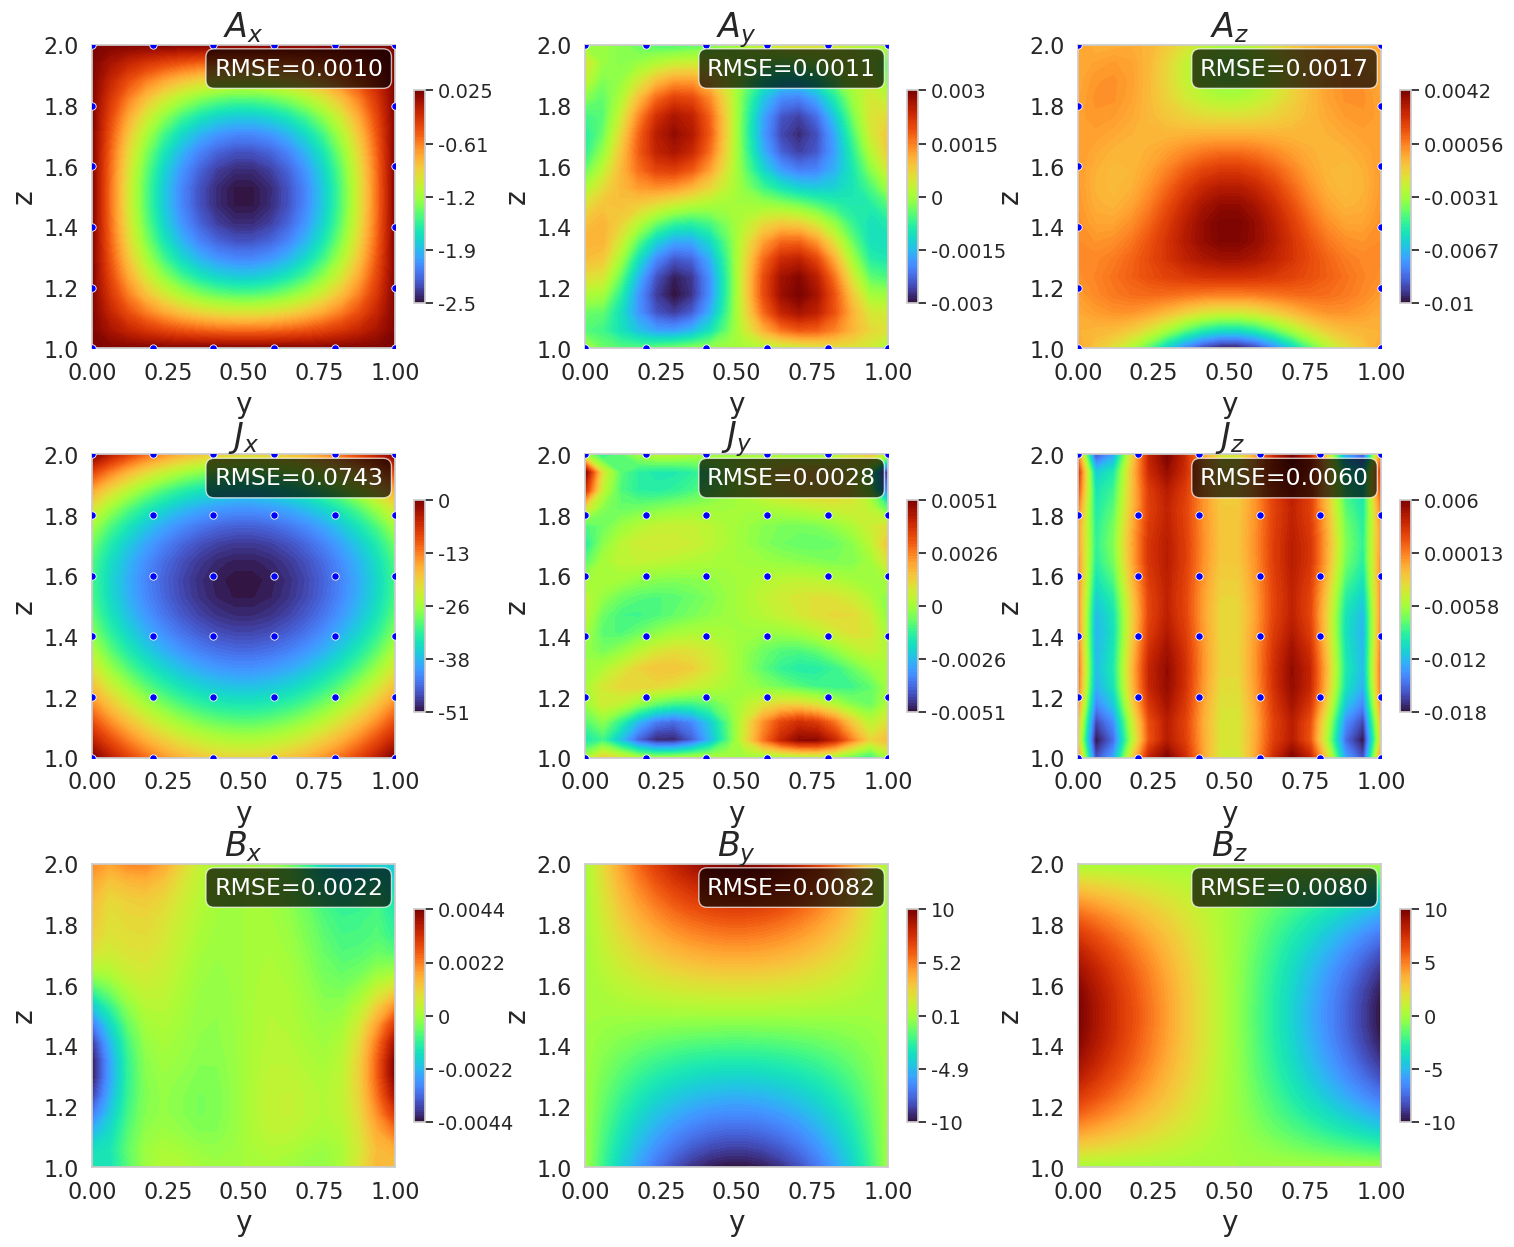

In [33]:
data_dir = os.path.join(output_data_ex3, "forward")
fname = f"Ex3_PIGP.npz"
data = load_run(data_dir, fname)

nrows, ncols = 3, 3
# CELL_W, CELL_H come from the GT cell -> panels identical in size to GT
fig, ax = plt.subplots(nrows, ncols, figsize=(ncols * CELL_W, nrows * CELL_H))
print("used training points", data.train_y.shape)

test_n = 18
xxx = torch.linspace(0, 1, test_n)
yyy = torch.linspace(0, 1, test_n)
zzz = torch.linspace(1, 2, test_n)
tx, ty, tz = torch.meshgrid(xxx, yyy, zzz, indexing="ij")

# put the slice on the test node closest to a training x-layer, so the training
# points actually lie in the visible y-z plane (solution has no x-dependence)
train_layers = torch.unique(data.train_x[:, 0])
x_near = float(train_layers[(train_layers - float(xxx[test_n // 2])).abs().argmin()])
x_idx = int((xxx - x_near).abs().argmin())
X = ty[x_idx, :, :]
Y = tz[x_idx, :, :]

#for visualizations:
title = [r"$A_x$", r"$A_y$", r"$A_z$", r"$J_x$", r"$J_y$", r"$J_z$", r"$B_x$", r"$B_y$", r"$B_z$"]
for i in range(9):
    a = ax[i // 3, i % 3]
    mask = data.test_x[:, -1] == i

    Z = data.mean[mask].reshape(test_n, test_n, test_n)[x_idx, :, :]

    cf = a.contourf(X, Y, Z, levels=100, cmap="turbo")
    cbar = fig.colorbar(cf, ax=a, shrink=0.7)
    style_cbar(cbar, cf)
    a.set_title(title[i], fontsize=24)

    # training points lying in the visible slice (B-field tasks have none)
    tmask = (data.train_x[:, -1] == i) & ((data.train_x[:, 0] - x_near).abs() < 1e-6)
    if bool(tmask.any()):
        a.scatter(data.train_x[tmask, 1], data.train_x[tmask, 2],
                  color="blue", edgecolors="white", linewidths=0.6, s=28, zorder=3)

    a.set_box_aspect(1)
    a.set_xlabel("y", fontsize=20)
    a.set_ylabel("z", fontsize=20)
    a.tick_params(labelsize=16)

    # per-task RMSE annotation (more readable: larger font, opaque box)
    rmse = float(np.sqrt(((np.asarray(data.mean[mask]) - np.asarray(data.test_y[mask]))**2).mean()))
    a.text(0.96, 0.96, f"RMSE={rmse:.4f}", transform=a.transAxes,
           ha="right", va="top", fontsize=17, color="white",
           bbox=dict(boxstyle="round,pad=0.35", fc="black", alpha=0.7))
fig.subplots_adjust(left=0.06, right=0.97, top=0.94, bottom=0.07, wspace=0.3, hspace=0.35)
plt.savefig(os.path.join(save_dir, "Ex3_forward_PIGP.pdf"), bbox_inches="tight")


# Quiver plot

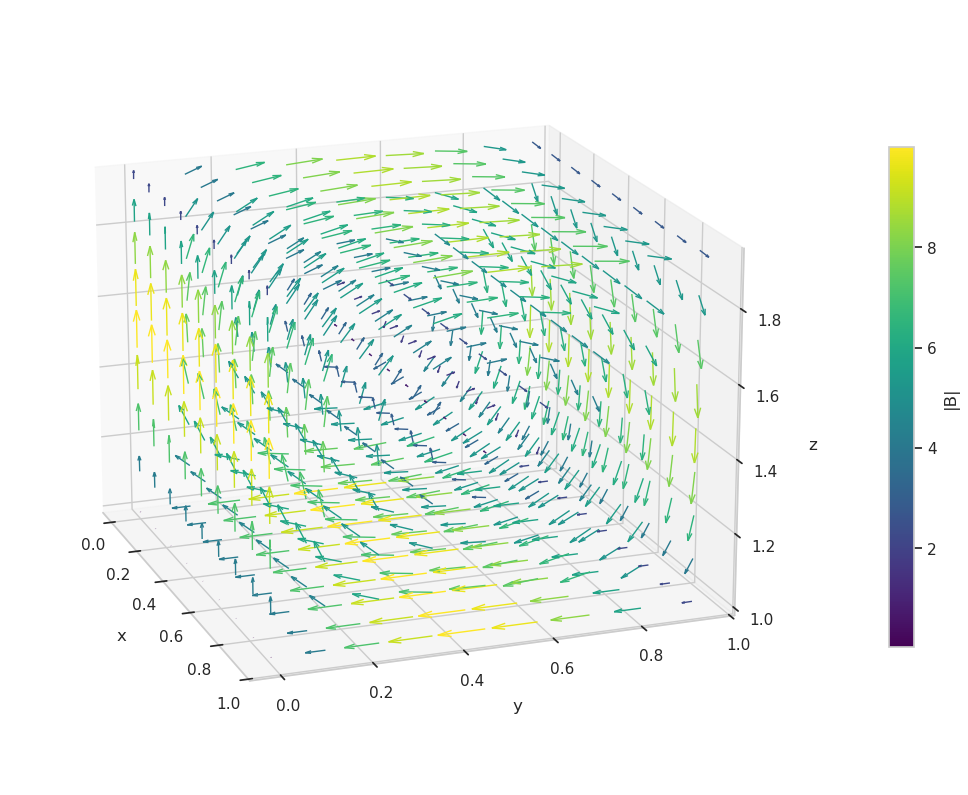

In [18]:
import os
import numpy as np
import torch
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401  (registers 3-D projection)
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize


def plot_quiver_3d(X, Y, Z, U, V, W, title="Magnetic field B", stride=1,
                   cmap="viridis", equal_length=True):
    """3-D quiver of a vector field sampled on a regular cube.

    X, Y, Z, U, V, W : equally-shaped 3-D arrays (grid coordinates and the three
                       field components on that grid).
    stride           : subsample factor along each axis (stride=1 -> every grid
                       node, i.e. one arrow per point along each edge).
    equal_length     : True  -> all arrows drawn the same length (a direction map;
                               magnitude is shown by colour only). Best when |B|
                               spans orders of magnitude, otherwise weak arrows
                               vanish across most of the cube.
                       False -> arrow length is proportional to |B|.
    Arrows are always coloured by |B|, one uniform colour per arrow.
    """
    sl = (slice(None, None, stride),) * 3
    X, Y, Z = X[sl], Y[sl], Z[sl]
    U, V, W = U[sl], V[sl], W[sl]

    mag = np.sqrt(U**2 + V**2 + W**2)
    spacing = min(np.diff(np.unique(a))[0] for a in (X, Y, Z) if np.unique(a).size > 1)
    if equal_length:
        length, normalize = 0.9 * spacing, True
    else:
        length, normalize = 0.9 * spacing / mag.max(), False

    # One uniform colour per arrow. mpl's 3-D quiver assembles the Line3DCollection
    # as [shafts (N), side-0 heads (N), side-1 heads (N)], every block in the same
    # arrow order, so the per-arrow colour is simply tiled 3x (NOT interleaved).
    norm = Normalize(vmin=float(mag.min()), vmax=float(mag.max()))
    base = plt.get_cmap(cmap)(norm(mag.ravel()))
    colors = np.tile(base, (3, 1))

    fig = plt.figure(figsize=(11, 9))
    ax = fig.add_subplot(111, projection="3d")
    ax.quiver(X, Y, Z, U, V, W, length=length, normalize=normalize,
              colors=colors, linewidth=1.0)
    ax.set_xlabel("x", labelpad=10)
    ax.set_ylabel("y", labelpad=10)
    ax.set_zlabel("z", labelpad=10)
    ax.set_title(title, fontsize=22)

    sm = ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array([])
    fig.colorbar(sm, ax=ax, shrink=0.6, pad=0.1, label="|B|")
    fig.tight_layout()
    return fig, ax


# ── forward GT problem: magnetic field B = (Bx, By, Bz) = last 3 tasks ─────────
# GT tasks: ["Ax", "Ay", "Az", "J", "GT", "Bx", "By", "Bz"]  →  Bx,By,Bz = 5,6,7
data_dir = os.path.join(output_data_ex3, "forward")
data = load_run(data_dir, "Ex3_GT.npz")

test_n = 18                      # test grid is an 18x18x18 cube
B_tasks = [5, 6, 7]

# grid coordinates (identical for every task) taken straight from test_x
pos = data.test_x[data.test_x[:, -1] == B_tasks[0], :3]
pos = pos.reshape(test_n, test_n, test_n, 3).numpy()
X, Y, Z = pos[..., 0], pos[..., 1], pos[..., 2]

U = data.mean[data.test_x[:, -1] == 5].reshape(test_n, test_n, test_n).numpy()
V = data.mean[data.test_x[:, -1] == 6].reshape(test_n, test_n, test_n).numpy()
W = data.mean[data.test_x[:, -1] == 7].reshape(test_n, test_n, test_n).numpy()

fig, ax = plot_quiver_3d(X, Y, Z, U, V, W,
                         title=None,#"Forward GT — magnetic field over the cube",
                         stride=2, equal_length=False)
ax.view_init(elev=18, azim=-20)   # face more of the y-z plane (look down the x-axis)
plt.savefig(os.path.join(save_dir, "Ex3_quiver_GT.pdf"), bbox_inches="tight")


# inverse problem visual check

used training points torch.Size([2500])


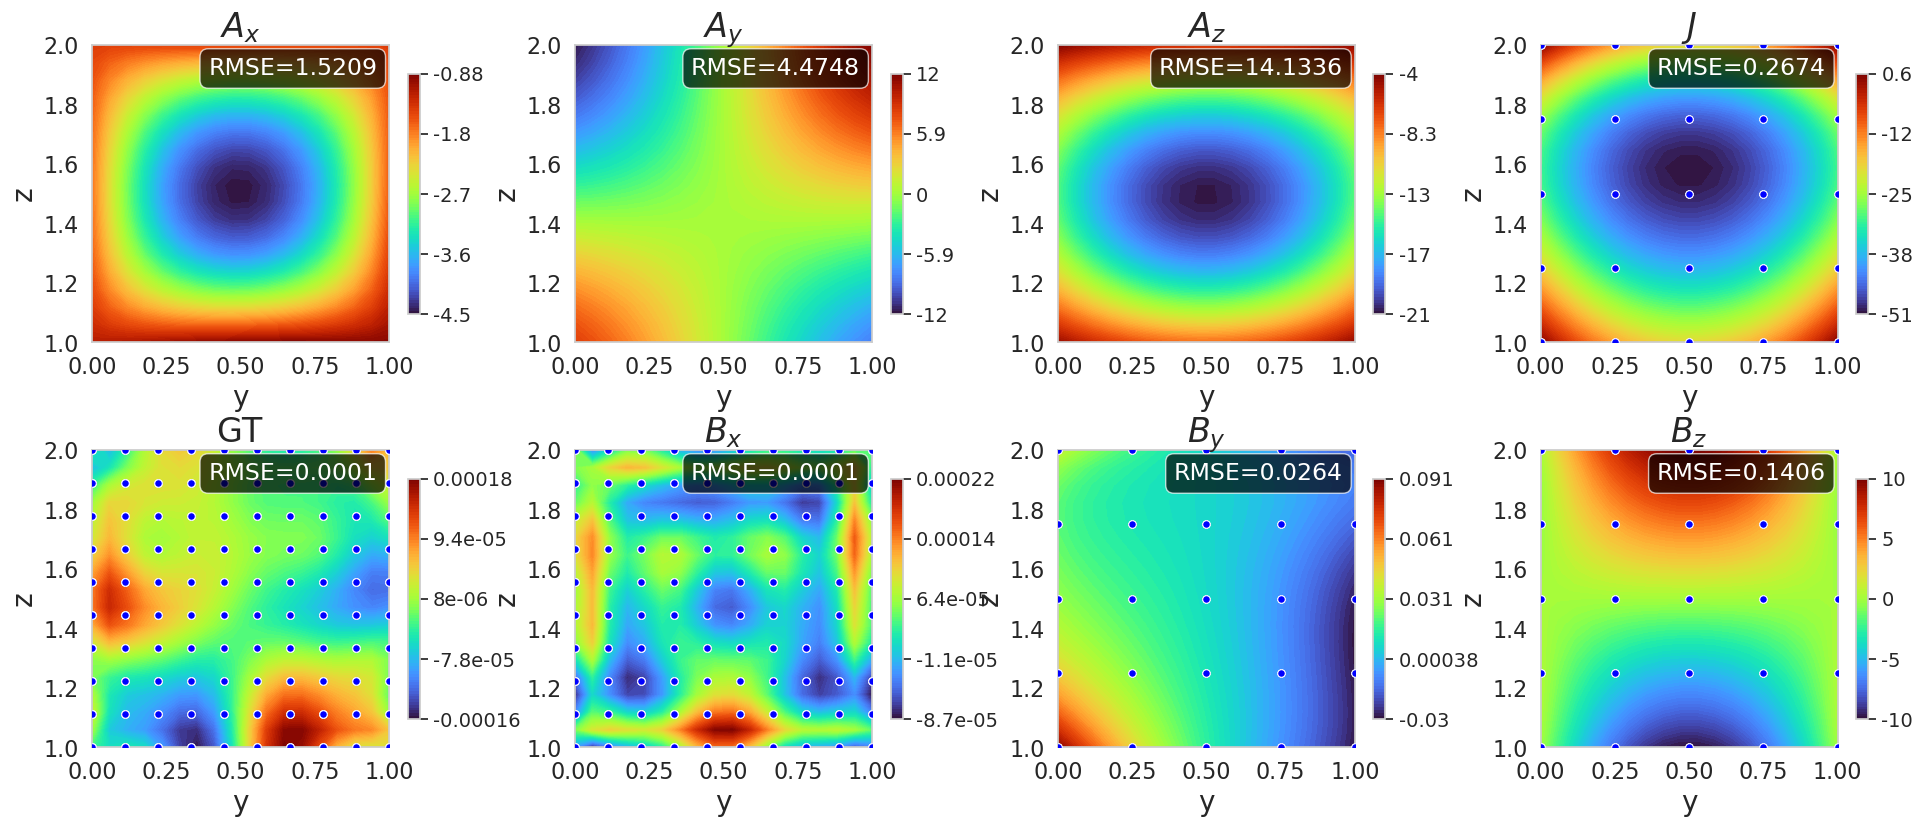

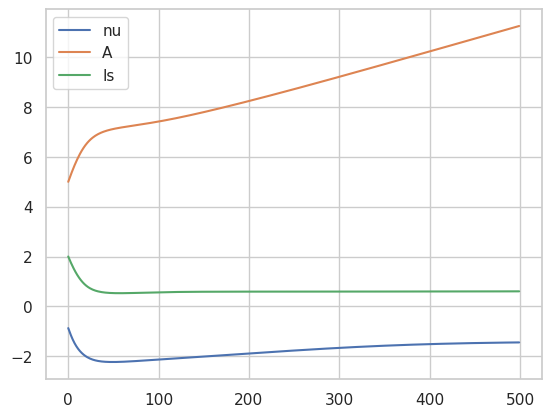

In [18]:
import matplotlib.ticker as mticker


def style_cbar(cbar, surf, n_ticks=5):
    """Paper-ready colorbar: few ticks, 2 significant digits, no scientific-
    notation offset header floating in the figure (same as Ex1 forward)."""
    vmin, vmax = surf.get_clim()
    cbar.set_ticks(np.linspace(vmin, vmax, n_ticks))
    cbar.ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:.2g}"))
    cbar.ax.yaxis.get_offset_text().set_visible(False)
    cbar.ax.tick_params(labelsize=14)


# per-subplot cell size in inches; shared with the PIGP cell so panels in both
# figures come out exactly the same size (figsize = n_cols/rows * cell size)
CELL_W, CELL_H = 5.0, 4.3

data_dir = os.path.join(output_data_ex3, "extra_npoints_extra_sigma")
mode = "PIGP"
npoints = 5
sigma = 0.1
run = 6
fname =  f"Ex3_{mode}_n{npoints}_sigma{sigma:.3f}_{run}.npz"
data = load_run(data_dir, fname)

nrows, ncols = 2, 4
fig, ax = plt.subplots(nrows, ncols, figsize=(ncols * CELL_W, nrows * CELL_H))
print("used training points", data.train_y.shape)

test_n = 18
xxx = torch.linspace(0, 1, test_n)
yyy = torch.linspace(0, 1, test_n)
zzz = torch.linspace(1, 2, test_n)
tx, ty, tz = torch.meshgrid(xxx, yyy, zzz, indexing="ij")

# put the slice on the test node closest to a training x-layer, so the training
# points actually lie in the visible y-z plane (solution has no x-dependence)
train_layers = torch.unique(data.train_x[:, 0])
x_near = float(train_layers[(train_layers - float(xxx[test_n // 2])).abs().argmin()])
x_idx = int((xxx - x_near).abs().argmin())
X = ty[x_idx, :, :]
Y = tz[x_idx, :, :]

#for visualizations:
title = [r"$A_x$", r"$A_y$", r"$A_z$", r"$J$", r"$\mathrm{GT}$", r"$B_x$", r"$B_y$", r"$B_z$"]
for i in range(8):
    a = ax[i // 4, i % 4]
    mask = data.test_x[:, -1] == i

    Z = data.mean[mask].reshape(test_n, test_n, test_n)[x_idx, :, :]

    cf = a.contourf(X, Y, Z, levels=100, cmap="turbo")
    cbar = fig.colorbar(cf, ax=a, shrink=0.7)
    style_cbar(cbar, cf)
    a.set_title(title[i], fontsize=24)

    # training points lying in the visible slice (B-field tasks have none)
    tmask = (data.train_x[:, -1] == i)# & ((data.train_x[:, 0] - x_near).abs() < 1e-6)
    #if bool(tmask.any()):
    a.scatter(data.train_x[tmask, 1], data.train_x[tmask, 2],
                  color="blue", edgecolors="white", linewidths=0.6, s=28, zorder=3)

    a.set_box_aspect(1)
    a.set_xlabel("y", fontsize=20)
    a.set_ylabel("z", fontsize=20)
    a.tick_params(labelsize=16)

    # per-task RMSE annotation (more readable: larger font, opaque box)
    rmse = float(np.sqrt(((np.asarray(data.mean[mask]) - np.asarray(data.test_y[mask]))**2).mean()))
    a.text(0.96, 0.96, f"RMSE={rmse:.4f}", transform=a.transAxes,
           ha="right", va="top", fontsize=17, color="white",
           bbox=dict(boxstyle="round,pad=0.35", fc="black", alpha=0.7))
fig.subplots_adjust(left=0.06, right=0.97, top=0.94, bottom=0.07, wspace=0.30, hspace=0.18)


# Posterior Grid evaluation

['nu0_vals' 'ls_vals' 'A_vals']


/tmp/ipykernel_11682/866416659.py:13: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  mll_clean = np.where(np.isfinite(mll), mll, -np.inf)


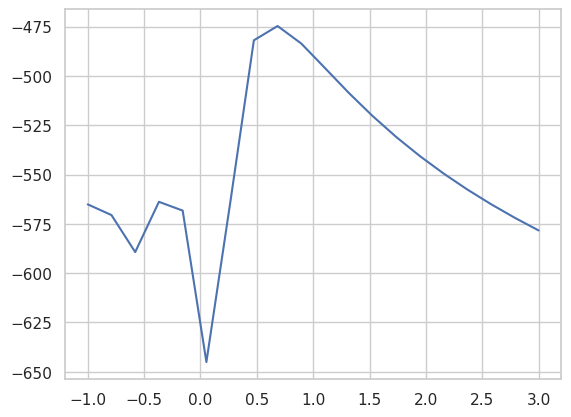

In [13]:
from scipy.special import logsumexp

grid_data = os.path.join(base_dir, "Experiment3_Magnetostatics", "grid_evaluation", "output_data")
data_dir = os.path.join(grid_data, "standard")

for method in ["GT", "PIGP"]:
    fname = f"{method}_n3_sigma0.20.npz"
    data = load_run(data_dir, fname)
    grid_shape = (len(data.nu0_vals), len(data.ls_vals), len(data.A_vals))
    if not np.isfinite(data.mll_values).all():
        raise ValueError(f"non-finite marginal likelihoods in {fname}")
    log_density = data.mll_values.reshape(grid_shape)
    density = logsumexp(log_density, axis=(-1, -2))
    plt.plot(data.nu0_vals, density, label=method)

plt.axvline(1.0, color="black", linestyle="--", label="true nu0")
plt.legend()

In [5]:
runs = 5
data_mode = ["extra_npoints_extra_sigma", "standard" ]
sigma_list = [0.001, 0.01, 0.1, 0.2]
n_list = [3, 5, 7]#, 5, 10]#,  30, 50]
modes = ["GT", "PIGP"]

for n_idx, npoints in enumerate(n_list):
    for sigma_idx, sigma in enumerate(sigma_list):
        for j, mode in enumerate(modes):
            data_dir = os.path.join(output_data_ex3, data_mode[j])

            for run in range(runs):
                fname = f"Ex3_{mode}_n{npoints}_sigma{sigma:.3f}_{run}.npz"
                #try:
                data = load_run(data_dir, fname)
                print(data)
                #except:  pass
               

namespace(mean=tensor([ 9.4610e+00,  9.4611e+00,  9.4613e+00,  ..., -4.1097e+00,
        -2.1830e+00,  1.2835e-04]), test_x=tensor([[0.0000, 0.0000, 1.0000, 0.0000],
        [0.0000, 0.0000, 1.0588, 0.0000],
        [0.0000, 0.0000, 1.1176, 0.0000],
        ...,
        [1.0000, 1.0000, 1.8824, 7.0000],
        [1.0000, 1.0000, 1.9412, 7.0000],
        [1.0000, 1.0000, 2.0000, 7.0000]]), train_x=tensor([[0.0000, 0.0000, 1.0000, 3.0000],
        [0.0000, 0.0000, 1.5000, 3.0000],
        [0.0000, 0.0000, 2.0000, 3.0000],
        ...,
        [1.0000, 1.0000, 1.0000, 7.0000],
        [1.0000, 1.0000, 1.5000, 7.0000],
        [1.0000, 1.0000, 2.0000, 7.0000]]), train_y=tensor([ 2.9956e-04, -3.0000e+01,  2.8321e-04,  ...,  2.0599e-03,
        -1.0001e+01, -1.3844e-04]), test_y=tensor([-0.0000, -0.0000, -0.0000,  ..., -4.1522, -2.2145,  0.0000]), MAP_estimates=tensor([1.0818, 6.4988, 0.8203]), covariance=tensor([[ 3.5904e-05, -1.9995e-04, -7.8310e-06],
        [-1.9995e-04,  7.5919e-02,  2.2

IOPub data rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_data_rate_limit`.

Current values:
ServerApp.iopub_data_rate_limit=1000000.0 (bytes/sec)
ServerApp.rate_limit_window=3.0 (secs)

